In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
sshikamaru_glaucoma_detection_path = kagglehub.dataset_download('sshikamaru/glaucoma-detection')

print('Data source import complete.')

Using Colab cache for faster access to the 'glaucoma-detection' dataset.
Data source import complete.


In [ ]:
import numpy as np
import pandas as pd

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/glaucoma-detection/glaucoma.csv
/kaggle/input/glaucoma-detection/Fundus_Train_Val_Data/Fundus_Scanes_Sorted/Validation/Glaucoma_Negative/537.jpg
/kaggle/input/glaucoma-detection/Fundus_Train_Val_Data/Fundus_Scanes_Sorted/Validation/Glaucoma_Negative/521.jpg
/kaggle/input/glaucoma-detection/Fundus_Train_Val_Data/Fundus_Scanes_Sorted/Validation/Glaucoma_Negative/539.jpg
/kaggle/input/glaucoma-detection/Fundus_Train_Val_Data/Fundus_Scanes_Sorted/Validation/Glaucoma_Negative/501.jpg
/kaggle/input/glaucoma-detection/Fundus_Train_Val_Data/Fundus_Scanes_Sorted/Validation/Glaucoma_Negative/544.jpg
/kaggle/input/glaucoma-detection/Fundus_Train_Val_Data/Fundus_Scanes_Sorted/Validation/Glaucoma_Negative/489.jpg
/kaggle/input/glaucoma-detection/Fundus_Train_Val_Data/Fundus_Scanes_Sorted/Validation/Glaucoma_Negative/576.jpg
/kaggle/input/glaucoma-detection/Fundus_Train_Val_Data/Fundus_Scanes_Sorted/Validation/Glaucoma_Negative/503.jpg
/kaggle/input/glaucoma-detection/Fundus_Train_Val_

we have these files -
```
/kaggle/input/glaucoma-detection/
 ├── glaucoma.csv
 ├── Fundus_Train_Val_Data/
 │   ├── Train/
 │   │   ├── Glaucoma_Positive/
 │   │   └── Glaucoma_Negative/
 │   └── Validation/
 │       ├── Glaucoma_Positive/
 │       └── Glaucoma_Negative/
 ├── ORIGA/
 └── ACRIMA/
```
dataset contains:
glaucoma.csv (metadata)
Organized training and validation images
Extra datasets (ORIGA, ACRIMA)

Fundus_Train_Val_Data → Kaggle dataset
ORIGA → Public glaucoma dataset
ACRIMA → Public glaucoma dataset

**ORIGA**
Full form: Online Retinal Fundus Image Database for Glaucoma Analysis
Contains fundus images of eyes with glaucoma-positive and glaucoma-negative labels.
Comes with annotations (like optic disc and cup segmentation) in .mat files.
Purpose → used to train or test glaucoma detection models.

**ACRIMA**
Another publicly available glaucoma dataset of fundus eye images.
Labeled images indicate healthy (negative) or glaucoma (positive) eyes.
No other diseases — purely focused on glaucoma detection.

Fundus refers to the interior surface of the eye, which includes:
- The retina (light-sensitive layer)
- The optic disc (where the optic nerve connects)
- Blood vessels

When doctors take a fundus image (or fundus photograph), they are capturing a picture of the back of the eye to check for diseases like glaucoma, diabetic retinopathy, or macular degeneration.

fundus images for glaucoma detection — the disease directly affects the optic disc and retinal nerve fibers, which are visible in these images.

In [ ]:
import os
import shutil  ## move, copy, or delete entire directories/files.
## os → like opening File Explorer and seeing files/folders
## shutil → like dragging, copying, or deleting files/folders
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings(action='ignore')

In [ ]:
import os
file_path = "/kaggle/input/glaucoma-detection/ORIGA/ORIGA/Images"
file_path_mat = "/kaggle/input/glaucoma-detection/ORIGA/ORIGA/Semi-automatic-annotations"

# List all files in the directory
all_files = os.listdir(file_path)
all_files_mat = os.listdir(file_path_mat)

jpg_files = [file for file in all_files if file.lower().endswith(".jpg")]
jpg_files_mat = [file for file in all_files_mat if file.lower().endswith(".mat")]

print("Number of images:", len(jpg_files))
print("Number of images:", len(jpg_files_mat))

Number of images: 650
Number of images: 650


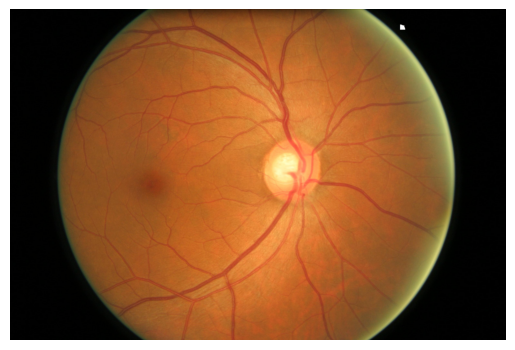

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Pick the image
img_path = os.path.join(file_path, jpg_files[1])
img = mpimg.imread(img_path)

plt.imshow(img)
plt.axis('off')
plt.show()


In [ ]:
from scipy.io import loadmat

# Pick .mat file
mat_path = os.path.join(file_path_mat, jpg_files_mat[1])
data = loadmat(mat_path)

print(data.keys())  # Shows all variables stored in the .mat file
print(data['mask'])

dict_keys(['__header__', '__version__', '__globals__', 'mask'])
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


In [ ]:
file_path = "/kaggle/input/glaucoma-detection/glaucoma.csv"
data = pd.read_csv(file_path)
print("Number of rows:", data.shape[0])
print("Number of columns:",data.shape[1])
print("Column names:", data.columns.tolist())

Number of rows: 650
Number of columns: 5
Column names: ['Filename', 'ExpCDR', 'Eye', 'Set', 'Glaucoma']


**ExpCDR**
Stands for Expert Cup-to-Disc Ratio.
Cup-to-Disc Ratio (CDR) → a number that shows the size of the optic cup relative to the optic disc.
Larger CDR → higher risk of glaucoma
This column is continuous (float numbers) and comes from expert ophthalmologists.

**Eye**
Indicates which eye the image is from:
"L" → Left eye
"R" → Right eye
Useful if you want to analyze left and right eyes separately.
OD → Oculus Dexter → right eye
OS → Oculus Sinister → left eye

**Set**
Tells you which part of the dataset this image belongs to:
"Train" → used for training the model
"Validation" → used to test the model during training

**Glaucoma**
The label for glaucoma presence:
1 → glaucoma-positive
0 → glaucoma-negative
This is what your model will learn to predict from the fundus image.

In [ ]:
data.sample(10)

,Filename,ExpCDR,Eye,Set,Glaucoma
91,092.jpg,0.4800,OD,A,0
598,599.jpg,0.6916,OD,B,0
647,648.jpg,0.5101,OS,A,1
282,283.jpg,0.4598,OD,B,1
496,497.jpg,0.7167,OS,B,0
256,257.jpg,0.6563,OS,B,0
423,424.jpg,0.7218,OD,A,1
90,091.jpg,0.4430,OS,A,0
241,242.jpg,0.5829,OS,B,0
377,378.jpg,0.7005,OD,B,0


In [ ]:
print(data['Eye'].unique(), "\n")
print(data['Set'].unique(), "\n")
print(data['Glaucoma'].unique(), "\n")

['OD' 'OS'] 

['A' 'B'] 

[0 1] 



In [ ]:
# data['Eye'].value_counts()
data['Set'].value_counts()


,count
Set,
A,325
B,325


In [ ]:
data['Eye'].value_counts()

,count
Eye,
OD,327
OS,323


In [ ]:
display(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 650 entries, 0 to 649
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Filename  650 non-null    object 
 1   ExpCDR    650 non-null    float64
 2   Eye       650 non-null    object 
 3   Set       650 non-null    object 
 4   Glaucoma  650 non-null    int64  
dtypes: float64(1), int64(1), object(3)
memory usage: 25.5+ KB


None

In [ ]:
display(data.isna().sum())

,0
Filename,0
ExpCDR,0
Eye,0
Set,0
Glaucoma,0


Glaucoma distribution:
Glaucoma
0    482
1    168
Name: count, dtype: int64


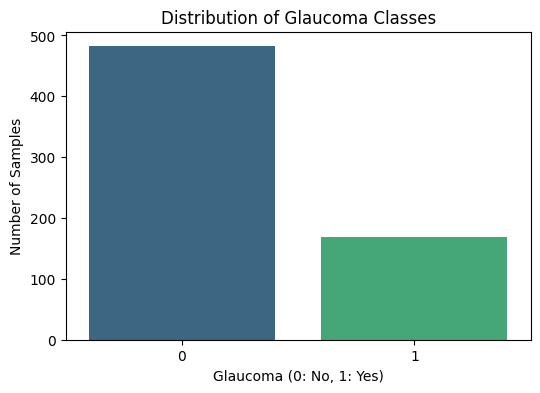

In [ ]:
import seaborn as sns
# Count the occurrences of each class in the 'Glaucoma' column
glaucoma_counts = data['Glaucoma'].value_counts()

# Print the counts to check for imbalance
print("Glaucoma distribution:")
print(glaucoma_counts)

# Plotting the bar chart
plt.figure(figsize=(6, 4))
sns.barplot(x=glaucoma_counts.index, y=glaucoma_counts.values, palette="viridis")
plt.title('Distribution of Glaucoma Classes')
plt.xlabel('Glaucoma (0: No, 1: Yes)')
plt.ylabel('Number of Samples')
plt.xticks(rotation=0)
plt.show()

#### imbalanced dataset

In [ ]:
# Paths
base_dir = "/kaggle/input/glaucoma-detection/ORIGA/ORIGA"
csv_file_path = "/kaggle/input/glaucoma-detection/glaucoma.csv"
image_dir = os.path.join(base_dir, "Images")
output_dir = "/kaggle/working/organized_data"

# Load the CSV file
data = pd.read_csv(csv_file_path)

# Create output directories for 'yes' and 'no'
yes_folder = os.path.join(output_dir, "yes")
no_folder = os.path.join(output_dir, "no")

# Subfolders for images and CSVs
yes_images_folder = os.path.join(yes_folder, "images")
yes_csv_folder = os.path.join(yes_folder, "csv")
no_images_folder = os.path.join(no_folder, "images")
no_csv_folder = os.path.join(no_folder, "csv")

# Create all necessary folders
## os.makedirs("folder", exist_ok=True)  # No error, just uses existing folder
## os.makedirs("folder")  # If "folder" exists, Python throws FileExistsError

os.makedirs(yes_images_folder, exist_ok=True)
os.makedirs(yes_csv_folder, exist_ok=True)
os.makedirs(no_images_folder, exist_ok=True)
os.makedirs(no_csv_folder, exist_ok=True)

# Separate data based on 'Glaucoma' values
yes_data = data[data["Glaucoma"] == 1]
no_data = data[data["Glaucoma"] == 0]

# Function to organize images and save CSVs
def organize_data(subset_data, images_folder, csv_folder):
    for _, row in subset_data.iterrows():
        filename = row["Filename"]
        src_path = os.path.join(image_dir, filename)
        dest_path = os.path.join(images_folder, filename)

        # Copy image
        if os.path.exists(src_path):
            shutil.copy(src_path, dest_path)

    # Save corresponding CSV in the 'csv' subfolder
    csv_path = os.path.join(csv_folder, "data.csv")
    subset_data.to_csv(csv_path, index=False)

# Organize data for 'yes' and 'no' classes
organize_data(yes_data, yes_images_folder, yes_csv_folder)
organize_data(no_data, no_images_folder, no_csv_folder)

print(f"Data organized into 'yes' and 'no' folders with separate subfolders for images and CSVs!")

Data organized into 'yes' and 'no' folders with separate subfolders for images and CSVs!


In [ ]:
no_path = "/kaggle/working/organized_data/no/images"
yes_path = "/kaggle/working/organized_data/yes/images"
# List all files in the directory
nofiles = os.listdir(no_path)
yesfiles = os.listdir(yes_path)

no_files = [file for file in nofiles if file.lower().endswith(".jpg")]
yes_files = [file for file in yesfiles if file.lower().endswith(".jpg")]
# Count the number of images
print("Number of images in no directory:", len(no_files))
print("Number of images in yes directory:", len(yes_files))

Number of images in no directory: 482
Number of images in yes directory: 168


#### Data Augmentation

In [ ]:
data = pd.read_csv("/kaggle/working/organized_data/yes/csv/data.csv")
data

,Filename,ExpCDR,Eye,Set,Glaucoma
0,036.jpg,0.5097,OD,A,1
1,037.jpg,0.3647,OD,A,1
2,041.jpg,0.6131,OD,B,1
3,050.jpg,0.6957,OD,B,1
4,069.jpg,0.7986,OD,B,1
...,...,...,...,...,...
163,645.jpg,0.7111,OS,A,1
164,646.jpg,0.6560,OD,A,1
165,647.jpg,0.7365,OD,A,1
166,648.jpg,0.5101,OS,A,1


In [ ]:
import os

ROOT = "/kaggle/input/glaucoma-detection"
print(os.listdir(ROOT))

print("\nInside Fundus_Train_Val_Data:")
print(os.listdir(ROOT + "/Fundus_Train_Val_Data"))


['Fundus_Train_Val_Data', 'ORIGA', 'glaucoma.csv', 'ACRIMA']

Inside Fundus_Train_Val_Data:
['Fundus_Scanes_Sorted']


In [ ]:
from PIL import Image # used to load and save images.
from tensorflow.keras.preprocessing.image import ImageDataGenerator
# Keras utility to perform image augmentation on the fly.
# Not on the fly: You generate and save all augmented images before training, taking extra storage.
# On the fly: During training, the model sees a new transformed version of the image each time, without permanently saving it.

# Paths
yes_images_folder = "/kaggle/working/organized_data/yes/images"
output_dir = "/kaggle/working/organized_data/aug_yes"
aug_images_folder = os.path.join(output_dir, "images")
aug_csv_folder = os.path.join(output_dir, "csv")
yes_csv_path = "/kaggle/working/organized_data/yes/csv/data.csv"

# Load the CSV file
yes_data = pd.read_csv(yes_csv_path)

# Create output directories for augmented data
os.makedirs(aug_images_folder, exist_ok=True)
os.makedirs(aug_csv_folder, exist_ok=True)

# Define augmentation transformations
datagen = ImageDataGenerator(
    rotation_range=10,       # rotate images ±15°
    width_shift_range=0.05,   # shift horizontally by 10% of image width
    height_shift_range=0.05,  # shift vertically by 10% of image height
    zoom_range=0.05,       # zoom in/out by 10%
    brightness_range=[0.9, 1.2],
    horizontal_flip=False,   # doesn't flip images horizontally
    fill_mode="nearest"    # fills empty pixels after transformation using nearest pixel value
)

# List to store new rows for CSV
augmented_rows = []

# Augment Images and Create New Data
for _, row in yes_data.iterrows():
    filename = row["Filename"]
    src_path = os.path.join(yes_images_folder, filename)

    if os.path.exists(src_path):
        # Load the original image
        img = Image.open(src_path)
        img_array = np.expand_dims(np.array(img), axis=0) ## converts in rgb format

        # Save the original image to the new folder
        new_filename = filename
        new_path = os.path.join(aug_images_folder, new_filename)
        img.save(new_path)

        # Add the original image row to augmented_rows
        new_row = row.copy()
        new_row["Filename"] = new_filename
        augmented_rows.append(new_row)

        # Generate 2 augmented images
        i = 1

        # datagen.flow(...) → generates augmented images infinitely, so we break after 2
        # batch_size = 1 -- gives 1 image in each iteration
        for batch in datagen.flow(img_array, batch_size=1):
            ## os.path.splitext() splits a filename into two parts: Name without extension → name, Extension → ext
            ## [image_01 , .jpg]
            augmented_filename = f"{os.path.splitext(filename)[0]}_{i}.jpg"
            augmented_image_path = os.path.join(aug_images_folder, augmented_filename)

            # Convert augmented batch to image
            # batch[0] -> extract the argumented array and then convert it into pixel values 0-255 by astype and then convert array to image
            augmented_img = Image.fromarray(batch[0].astype("uint8"))
            augmented_img.save(augmented_image_path)  ## saves the image

            # Add new augmented image row to augmented_rows -- to csv
            new_augmented_row = row.copy()
            new_augmented_row["Filename"] = augmented_filename
            augmented_rows.append(new_augmented_row)

            i += 1
            if i > 2:  # We need exactly 2 augmented images (total of 3 images: original + 2 augmented)
                break

# Save updated CSV with 3 images (original + 2 augmented) for each entry
augmented_data = pd.DataFrame(augmented_rows)
augmented_data.to_csv(os.path.join(aug_csv_folder, "data.csv"), index=False)

print(f"Augmented images saved to '{aug_images_folder}' and CSV updated at '{aug_csv_folder}/data.csv'.")

Augmented images saved to '/kaggle/working/organized_data/aug_yes/images' and CSV updated at '/kaggle/working/organized_data/aug_yes/csv/data.csv'.


In [ ]:
file_path = "/kaggle/working/organized_data/aug_yes/images"

# List all files in the directory
all_files = os.listdir(file_path)

aug_files = [file for file in all_files if file.lower().endswith(".jpg")]
# Count the number of images
print("Number of total augmented images:", len(aug_files))

Number of total augmented images: 504


In [ ]:
file_path = "/kaggle/working/organized_data/aug_yes/csv/data.csv"
df = pd.read_csv(file_path)
print("Number of rows:", df.shape[0])
print("Number of columns:",df.shape[1])
print("Column names:", df.columns.tolist())

Number of rows: 504
Number of columns: 5
Column names: ['Filename', 'ExpCDR', 'Eye', 'Set', 'Glaucoma']


Yes images :  504
No images :  482


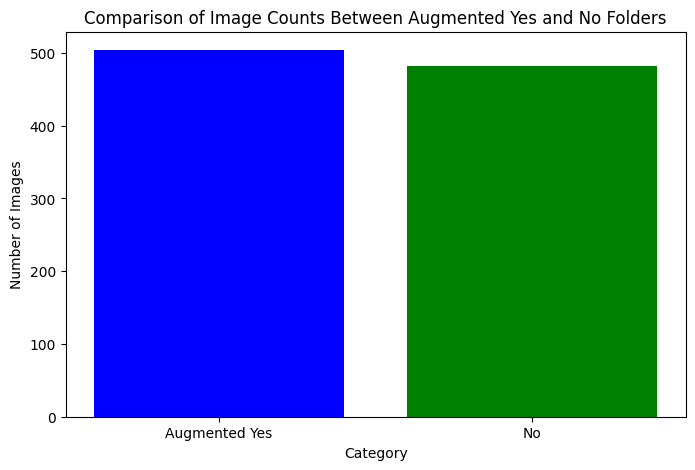

In [ ]:
# Paths to the image folders
aug_yes_images_folder = "/kaggle/working/organized_data/aug_yes/images"
no_images_folder = "/kaggle/working/organized_data/no/images"

# Count the number of images in each folder
num_aug_yes_images = len([img for img in os.listdir(aug_yes_images_folder) if img.endswith(".jpg")])
num_no_images = len([img for img in os.listdir(no_images_folder) if img.endswith(".jpg")])

print("Yes images : ", num_aug_yes_images)
print("No images : ", num_no_images)

# Data for the bar chart
categories = ['Augmented Yes', 'No']
counts = [num_aug_yes_images, num_no_images]

# Plot the bar chart
plt.figure(figsize=(8, 5))
plt.bar(categories, counts, color=['blue', 'green'])
plt.title('Comparison of Image Counts Between Augmented Yes and No Folders')
plt.xlabel('Category')
plt.ylabel('Number of Images')
plt.grid(False)
plt.show()

### Now the dataset is balanced

In [ ]:
from tensorflow.keras.utils import to_categorical
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, LearningRateScheduler

In [ ]:
import os
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.utils import to_categorical

In [ ]:
# Paths for aug_yes and no
aug_yes_csv_path = "/kaggle/working/organized_data/aug_yes/csv/data.csv"
aug_yes_images_folder = "/kaggle/working/organized_data/aug_yes/images"

no_csv_path = "/kaggle/working/organized_data/no/csv/data.csv"
no_images_folder = "/kaggle/working/organized_data/no/images"

# Load CSVs
data_yes = pd.read_csv(aug_yes_csv_path)
data_yes['label'] = 1  # Assign label 1 for "yes"

data_no = pd.read_csv(no_csv_path)
data_no['label'] = 0  # Assign label 0 for "no"

# Combine both classes and shuffle
data = pd.concat([data_yes, data_no], ignore_index=True)
data = data.sample(frac=1, random_state=42).reset_index(drop=True)

# Split data into train, validation, and test sets (70:15:15) while maintaining label balance
train_data, temp_data = train_test_split(data, test_size=0.3, stratify=data['label'], random_state=42)
valid_data, test_data = train_test_split(temp_data, test_size=0.5, stratify=temp_data['label'], random_state=42)

# Function to preprocess images and create data lists
def preprocess_and_load_data(data_subset, folder_paths):
    images = []
    labels = []

    for _, row in data_subset.iterrows():
        filename = row["Filename"]
        label = row["label"]
        # Determine the folder based on the label
        image_folder = folder_paths['yes'] if label == 1 else folder_paths['no']
        image_path = os.path.join(image_folder, filename)

        if os.path.exists(image_path):
            # Load the image and resize to (224, 224) for ResNet50
            img = load_img(image_path, target_size=(224, 224))
            img_array = img_to_array(img)
            img_preprocessed = preprocess_input(img_array)  # Normalizing the pixel values

            images.append(img_preprocessed)
            labels.append(label)

    return np.array(images), np.array(labels)

# Define image folder paths for both labels
folder_paths = {
    "yes": aug_yes_images_folder,
    "no": no_images_folder
}

# Preprocess and load data for train, validation, and test sets
train_images, train_labels = preprocess_and_load_data(train_data, folder_paths)
valid_images, valid_labels = preprocess_and_load_data(valid_data, folder_paths)
test_images, test_labels = preprocess_and_load_data(test_data, folder_paths)

# One-hot encode the labels
num_classes = 2  # Glaucoma has two classes: 0 and 1
train_labels = to_categorical(train_labels, num_classes=num_classes)
valid_labels = to_categorical(valid_labels, num_classes=num_classes)
test_labels = to_categorical(test_labels, num_classes=num_classes)

# print(train_labels)
# Output the shapes of the data
print(f"Train images shape: {train_images.shape}")
print(f"Train labels shape: {train_labels.shape}")
print(f"Validation images shape: {valid_images.shape}")
print(f"Validation labels shape: {valid_labels.shape}")
print(f"Test images shape: {test_images.shape}")
print(f"Test labels shape: {test_labels.shape}")

# Print class distribution in each split
print("Class distribution in Train:", np.sum(train_labels, axis=0))
print("Class distribution in Validation:", np.sum(valid_labels, axis=0))
print("Class distribution in Test:", np.sum(test_labels, axis=0))

Train images shape: (690, 224, 224, 3)
Train labels shape: (690, 2)
Validation images shape: (148, 224, 224, 3)
Validation labels shape: (148, 2)
Test images shape: (148, 224, 224, 3)
Test labels shape: (148, 2)
Class distribution in Train: [337. 353.]
Class distribution in Validation: [72. 76.]
Class distribution in Test: [73. 75.]


We are resizing the input because :-
- Deep learning models like ResNet50 require fixed-size input images.
- Example: ResNet50 expects (224, 224, 3)
- Original fundus images may be different sizes (e.g., 600×400, 1024×768)
- Resizing ensures consistency so all images can pass through the network

In [ ]:
data_yes

,Filename,ExpCDR,Eye,Set,Glaucoma,label
0,036.jpg,0.5097,OD,A,1,1
1,036_1.jpg,0.5097,OD,A,1,1
2,036_2.jpg,0.5097,OD,A,1,1
3,037.jpg,0.3647,OD,A,1,1
4,037_1.jpg,0.3647,OD,A,1,1
...,...,...,...,...,...,...
499,648_1.jpg,0.5101,OS,A,1,1
500,648_2.jpg,0.5101,OS,A,1,1
501,650.jpg,0.6195,OS,B,1,1
502,650_1.jpg,0.6195,OS,B,1,1


In [ ]:
data

,Filename,ExpCDR,Eye,Set,Glaucoma,label
0,124.jpg,0.8207,OS,A,0,0
1,624_1.jpg,0.6772,OS,A,1,1
2,263.jpg,0.5604,OD,A,0,0
3,618_1.jpg,0.6203,OD,A,1,1
4,458_2.jpg,0.6713,OD,B,1,1
...,...,...,...,...,...,...
981,269_1.jpg,0.7580,OS,B,1,1
982,457.jpg,0.6742,OS,B,1,1
983,447.jpg,0.5379,OS,B,0,0
984,618.jpg,0.6203,OD,A,1,1


In [ ]:
import os
import pandas as pd

ROOT = "/kaggle/input/glaucoma-detection/Fundus_Train_Val_Data/Fundus_Scanes_Sorted"

all_data = []

for subset in ["Train", "Validation"]:
    for label in ["Glaucoma_Positive", "Glaucoma_Negative"]:
        folder = os.path.join(ROOT, subset, label)
        for filename in os.listdir(folder):
            if filename.lower().endswith((".jpg", ".jpeg", ".png")):
                all_data.append({
                    "image_path": os.path.join(folder, filename),
                    "label": 1 if label=="Glaucoma_Positive" else 0
                })

data = pd.DataFrame(all_data)
print(data.head())
print("Total images:", len(data))
print("Positive:", sum(data.label==1))
print("Negative:", sum(data.label==0))


                                          image_path  label
0  /kaggle/input/glaucoma-detection/Fundus_Train_...      1
1  /kaggle/input/glaucoma-detection/Fundus_Train_...      1
2  /kaggle/input/glaucoma-detection/Fundus_Train_...      1
3  /kaggle/input/glaucoma-detection/Fundus_Train_...      1
4  /kaggle/input/glaucoma-detection/Fundus_Train_...      1
Total images: 650
Positive: 168
Negative: 482


In [ ]:
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(
    data, test_size=0.2, stratify=data["label"], random_state=42
)

val_df, test_df = train_test_split(
    temp_df, test_size=0.5, stratify=temp_df["label"], random_state=42
)

print(len(train_df), len(val_df), len(test_df))


520 65 65


In [ ]:
# Convert numeric labels → class names
train_df["label"] = train_df["label"].map({0: "Glaucoma_Negative", 1: "Glaucoma_Positive"})
val_df["label"]   = val_df["label"].map({0: "Glaucoma_Negative", 1: "Glaucoma_Positive"})
test_df["label"]  = test_df["label"].map({0: "Glaucoma_Negative", 1: "Glaucoma_Positive"})


In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.10,
    height_shift_range=0.10,
    shear_range=0.10,
    zoom_range=0.15,
    brightness_range=(0.7, 1.3),
    horizontal_flip=True,
    fill_mode="nearest"
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_dataframe(
    train_df,
    x_col="image_path",
    y_col="label",
    target_size=(224, 224),
    batch_size=16,
    class_mode="binary",
    shuffle=True
)

val_generator = val_test_datagen.flow_from_dataframe(
    val_df,
    x_col="image_path",
    y_col="label",
    target_size=(224, 224),
    batch_size=16,
    class_mode="binary",
    shuffle=False
)

test_generator = val_test_datagen.flow_from_dataframe(
    test_df,
    x_col="image_path",
    y_col="label",
    target_size=(224, 224),
    batch_size=16,
    class_mode="binary",
    shuffle=False
)


Found 520 validated image filenames belonging to 2 classes.
Found 65 validated image filenames belonging to 2 classes.
Found 65 validated image filenames belonging to 2 classes.


In [ ]:


# # Define ResNet50 model
# def create_resnet50_model(input_shape, num_classes):
#     # Load ResNet50 base model with pre-trained weights
#     base_model = ResNet50(weights='imagenet', include_top=False, input_shape=input_shape)

#     # Freeze the base model layers for transfer learning
#     for layer in base_model.layers:
#         layer.trainable = False

#     # Add custom classification layers
#     x = base_model.output
#     x = GlobalAveragePooling2D()(x)
#     x = Dense(256, activation='relu')(x)
#     predictions = Dense(num_classes, activation='softmax')(x)

#     # Compile the model
#     model = Model(inputs=base_model.input, outputs=predictions)
#     model.compile(optimizer=Adam(learning_rate=1e-4),
#                   loss=tf.losses.CategoricalCrossentropy(),
#                   metrics=['accuracy'])
#     return model

from tensorflow.keras.layers import Dropout


def create_resnet50_model(input_shape, num_classes):

    base_model = ResNet50(
        weights='imagenet',
        include_top=False,
        input_shape=input_shape
    )

    # Unfreeze last 30 layers
    for layer in base_model.layers[:-30]:
        layer.trainable = False
    for layer in base_model.layers[-30:]:
        layer.trainable = True

    x = GlobalAveragePooling2D()(base_model.output)

    x = Dense(256, activation='relu',
              kernel_regularizer=tf.keras.regularizers.l2(0.001))(x)
    x = Dropout(0.4)(x)

    predictions = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=base_model.input, outputs=predictions)

    model.compile(
        optimizer=Adam(learning_rate=1e-5),
        loss=tf.losses.CategoricalCrossentropy(),
        metrics=['accuracy']
    )

    return model


In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint, LearningRateScheduler
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
def create_resnet50_model(input_shape, num_classes):

    base_model = ResNet50(
        weights="imagenet",
        include_top=False,
        input_shape=input_shape
    )

    # Unfreeze last 50 layers except BatchNorm
    for layer in base_model.layers:
        if isinstance(layer, tf.keras.layers.BatchNormalization):
            layer.trainable = False
        else:
            layer.trainable = True

    x = GlobalAveragePooling2D()(base_model.output)
    x = BatchNormalization()(x)

    x = Dense(512, activation='relu',
              kernel_regularizer=tf.keras.regularizers.l2(0.001))(x)
    x = Dropout(0.5)(x)

    x = Dense(128, activation='relu',
              kernel_regularizer=tf.keras.regularizers.l2(0.001))(x)
    x = Dropout(0.4)(x)

    outputs = Dense(num_classes, activation="softmax")(x)

    model = Model(base_model.input, outputs)

    model.compile(
        optimizer=Adam(learning_rate=1e-5),
        loss="categorical_crossentropy", # Changed from sparse_categorical_crossentropy
        metrics=["accuracy"]
    )

    return model

In [ ]:
# def lr_schedule(epoch, lr):
#     if epoch in [5, 10, 20]:  # smoother decay
#         return lr * 0.5
#     return lr

# learning_rate_scheduler = LearningRateScheduler(lr_schedule)

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True
)

lr_reducer = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=3,
    min_lr=1e-7
)

checkpoint = ModelCheckpoint(
    "best_resnet.h5", save_best_only=True, monitor="val_loss"
)


In [ ]:
data_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    width_shift_range=0.08,
    height_shift_range=0.08,
    zoom_range=0.10,
    brightness_range=(0.85, 1.15),
    horizontal_flip=True
)


In [ ]:
# input_shape = (224, 224, 3)
# num_classes = 2

# model = create_resnet50_model(input_shape, num_classes)

# history = model.fit(
#     data_gen.flow(train_images, train_labels, batch_size=16),
#     validation_data=(valid_images, valid_labels),
#     epochs=65,
#     callbacks=[early_stopping, lr_reducer, learning_rate_scheduler, checkpoint]
# )

model = create_resnet50_model((224,224,3), 2)

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=60,
    callbacks=[early_stopping, lr_reducer, checkpoint]
)


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
Epoch 1/60
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5695 - loss: 1.7247

33/33 ━━━━━━━━━━━━━━━━━━━━ 86s 2s/step - accuracy: 0.5703 - loss: 1.7236 - val_accuracy: 0.7385 - val_loss: 1.5883 - learning_rate: 1.0000e-05
Epoch 2/60
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 635ms/step - accuracy: 0.6614 - loss: 1.6606

33/33 ━━━━━━━━━━━━━━━━━━━━ 24s 722ms/step - accuracy: 0.6613 - loss: 1.6605 - val_accuracy: 0.7385 - val_loss: 1.5787 - learning_rate: 1.0000e-05
Epoch 3/60
33/33 ━━━━━━━━━━━━━━━━━━━━ 23s 693ms/step - accuracy: 0.6051 - loss: 1.6795 - val_accuracy: 0.7385 - val_loss: 1.5908 - learning_rate: 1.0000e-05
Epoch 4/60
33/33 ━━━━━━━━━━━━━━━━━━━━ 24s 720ms/step - accuracy: 0.6976 - loss: 1.6376 - val_accuracy: 0.2615 - val_loss: 1.8375 - learning_rate: 1.0000e-05
Epoch 5/60
33/33 ━━━━━━━━━━━━━━━━━━━━ 23s 696ms/step - accuracy: 0.7105 - loss: 1.5959 - val_accuracy: 0.7385 - val_loss: 1.6589 - learning_rate: 1.0000e-05
Epoch 6/60
33/33 ━━━━━━━━━━━━━━━━━━━━ 24s 727ms/step - accuracy: 0.7108 - loss: 1.6054 - val_accuracy: 0.7385 - val_loss: 1.7208 - learning_rate: 3.0000e-06
Epoch 7/60
33/33 ━━━━━━━━━━━━━━━━━━━━ 23s 693ms/step - accuracy: 0.7162 - loss: 1.5896 - val_accuracy: 0.7385 - val_loss: 1.6423 - learning_rate: 3.0000e-06
Epoch 8/60
33/33 ━━━━━━━━━━━━━━━━━━━━ 23s 691ms/step - accuracy: 0.71

33/33 ━━━━━━━━━━━━━━━━━━━━ 30s 903ms/step - accuracy: 0.6945 - loss: 1.6014 - val_accuracy: 0.7385 - val_loss: 1.5770 - learning_rate: 2.7000e-07
Epoch 14/60
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 640ms/step - accuracy: 0.7177 - loss: 1.5699

33/33 ━━━━━━━━━━━━━━━━━━━━ 25s 741ms/step - accuracy: 0.7178 - loss: 1.5700 - val_accuracy: 0.7385 - val_loss: 1.5722 - learning_rate: 2.7000e-07
Epoch 15/60
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 641ms/step - accuracy: 0.6548 - loss: 1.6516

33/33 ━━━━━━━━━━━━━━━━━━━━ 25s 741ms/step - accuracy: 0.6556 - loss: 1.6508 - val_accuracy: 0.7385 - val_loss: 1.5635 - learning_rate: 2.7000e-07
Epoch 16/60
33/33 ━━━━━━━━━━━━━━━━━━━━ 23s 707ms/step - accuracy: 0.7335 - loss: 1.5932 - val_accuracy: 0.7385 - val_loss: 1.5666 - learning_rate: 2.7000e-07
Epoch 17/60
33/33 ━━━━━━━━━━━━━━━━━━━━ 23s 682ms/step - accuracy: 0.7234 - loss: 1.5837 - val_accuracy: 0.7385 - val_loss: 1.5699 - learning_rate: 2.7000e-07
Epoch 18/60
33/33 ━━━━━━━━━━━━━━━━━━━━ 23s 700ms/step - accuracy: 0.6848 - loss: 1.6354 - val_accuracy: 0.7385 - val_loss: 1.5684 - learning_rate: 2.7000e-07
Epoch 19/60
33/33 ━━━━━━━━━━━━━━━━━━━━ 22s 662ms/step - accuracy: 0.7433 - loss: 1.5843 - val_accuracy: 0.7385 - val_loss: 1.5639 - learning_rate: 1.0000e-07
Epoch 20/60
33/33 ━━━━━━━━━━━━━━━━━━━━ 23s 685ms/step - accuracy: 0.7162 - loss: 1.5987 - val_accuracy: 0.7385 - val_loss: 1.5657 - learning_rate: 1.0000e-07
Epoch 21/60
33/33 ━━━━━━━━━━━━━━━━━━━━ 23s 689ms/step - accuracy

In [ ]:
test_loss, test_acc = model.evaluate(test_generator)
print("Test Accuracy:", test_acc)


5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 360ms/step - accuracy: 0.7705 - loss: 1.5267
Test Accuracy: 0.7384615540504456


As resnet 50 is pretrained on imagenet dataset(~14 million images, 1000 classes).
ResNet50 is pretrained on ImageNet, so it already learned low-level features like:
- edges, corners, textures (in early layers)
- shapes, patterns, combinations (in deeper layers)

include_top = false
we are removing the output layer. Because imagenet has 1k classes while we have only 2. Hence we add ours

okay so for backward propogation we don't want our weights get updated. Hence freezed the basic layers

the output of the layer is converted into 1D array by GlobalAveragePooling2D().
Input: 3D feature map from last convolutional layer → shape (H, W, C)
Operation: Take average of each feature map → output (C,) 1D vector
Example:
If feature map = (7, 7, 2048)
GlobalAveragePooling → (2048,)
- Reduces number of parameters → avoids overfitting
- Keeps spatial information summarized → each channel represents a strong feature
- Works better than flattening → more robust

added 2 layers
Dense(256, activation='relu') → fully connected layer with 256 neurons → learns patterns for glaucoma detection
Dense(num_classes, activation='softmax') → output layer



In [ ]:
save_dir = '/kaggle/working/'
os.makedirs(save_dir, exist_ok=True)

# Ensure file paths are valid
weights_path = './resnet50_model_weights.weights.h5'
model_path = './resnet50_model.h5'

# Debug paths
print(f"Saving weights to: {weights_path}")
print(f"Saving model to: {model_path}")

# Save weights and model
model.save_weights(weights_path)
model.save(model_path)

print("Model and weights saved successfully!")

Saving weights to: ./resnet50_model_weights.weights.h5
Saving model to: ./resnet50_model.h5


Model and weights saved successfully!


In [ ]:
# Evaluate the model
results = model.evaluate(valid_images, valid_labels, batch_size=32)
print(f"Validation Loss: {results[0]}, Validation Accuracy: {results[1]}")

ValueError: Cannot take the length of shape with unknown rank.

In [ ]:
import numpy as np
import tensorflow as tf
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Debug: Check test shapes and content
print(f"Test images shape: {test_images.shape}")
print(f"Test labels shape: {test_labels.shape}")
print(f"Test labels content: {test_labels[:10]}")  # Sample labels

# If test_labels is already in integer format, use it directly
test_labels_int = test_labels if len(test_labels.shape) == 1 else np.argmax(test_labels, axis=1)

# Load your trained model
model = tf.keras.models.load_model("/content/resnet50_model.h5")  # Path to your trained model

# Predict using the trained model
predictions = model.predict(test_images)
predicted_classes = np.argmax(predictions, axis=1)  # Convert predictions to class indices

# Calculate accuracy
accuracy = accuracy_score(test_labels_int, predicted_classes)
print(f"Manual Test Accuracy: {accuracy * 100:.2f}%")

# Classification Report
unique_classes = np.unique(test_labels_int)  # Get unique classes
target_names = [f"Class {cls}" for cls in unique_classes]  # Dynamically create target names

print("\nClassification Report:")
print(classification_report(test_labels_int, predicted_classes, target_names=target_names))

# Confusion Matrix
print("\nConfusion Matrix:")
conf_matrix = confusion_matrix(test_labels_int, predicted_classes)
print(conf_matrix)

#  print predictions for each image
for i, (true_label, pred_label) in enumerate(zip(test_labels_int, predicted_classes)):
    print(f"Image {i + 1}: True Label: {true_label}, Predicted Label: {pred_label}")

Test images shape: (148, 224, 224, 3)
Test labels shape: (148, 2)
Test labels content: [[0. 1.]
 [0. 1.]
 [1. 0.]
 [0. 1.]
 [0. 1.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [0. 1.]
 [0. 1.]]


5/5 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step
Manual Test Accuracy: 49.32%

Classification Report:
              precision    recall  f1-score   support

     Class 0       0.49      1.00      0.66        73
     Class 1       0.00      0.00      0.00        75

    accuracy                           0.49       148
   macro avg       0.25      0.50      0.33       148
weighted avg       0.24      0.49      0.33       148


Confusion Matrix:
[[73  0]
 [75  0]]
Image 1: True Label: 1, Predicted Label: 0
Image 2: True Label: 1, Predicted Label: 0
Image 3: True Label: 0, Predicted Label: 0
Image 4: True Label: 1, Predicted Label: 0
Image 5: True Label: 1, Predicted Label: 0
Image 6: True Label: 0, Predicted Label: 0
Image 7: True Label: 0, Predicted Label: 0
Image 8: True Label: 0, Predicted Label: 0
Image 9: True Label: 1, Predicted Label: 0
Image 10: True Label: 1, Predicted Label: 0
Image 11: True Label: 1, Predicted Label: 0
Image 12: True Label: 0, Predicted Label: 0
Image 13: True Label: 0, P

In [ ]:
# Define data augmentation for the training set
data_gen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

In [ ]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
import tensorflow as tf

def create_vgg16_model(input_shape, num_classes):

    base_model = VGG16(
        weights='imagenet',
        include_top=False,
        input_shape=input_shape
    )

    # Unfreeze last 4 layers
    for layer in base_model.layers[:-4]:
        layer.trainable = False
    for layer in base_model.layers[-4:]:
        layer.trainable = True

    x = GlobalAveragePooling2D()(base_model.output)

    x = Dense(256, activation='relu',
              kernel_regularizer=tf.keras.regularizers.l2(0.001))(x)
    x = Dropout(0.5)(x)

    predictions = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=base_model.input, outputs=predictions)

    model.compile(
        optimizer=Adam(learning_rate=1e-5),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model


In [ ]:
# early_stopping = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)
# learning_rate_scheduler = LearningRateScheduler(lr_schedule)

def lr_schedule(epoch, lr):
    # Example: Decrease learning rate by 10% every 5 epochs
    if epoch % 5 == 0 and epoch > 0:
        lr *= 0.5
    return float(lr)  # Ensure the return value is a float

# Create LearningRateScheduler
# Keras callback that applies lr_schedule function every epoch
learning_rate_scheduler = LearningRateScheduler(lr_schedule)

In [ ]:
# Model configuration
input_shape = (224, 224, 3)
num_classes = 2  # Yes and No classes
vgg16_model = create_vgg16_model(input_shape, num_classes)

# Train the VGG16 model
history_vgg16 = vgg16_model.fit(
    train_images,  # Training images
    train_labels,  # One-hot encoded training labels
    batch_size=16,
    epochs=60,
    validation_data=(valid_images, valid_labels),  # Validation data
    callbacks=[early_stopping, learning_rate_scheduler]
)


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Epoch 1/60
44/44 ━━━━━━━━━━━━━━━━━━━━ 26s 316ms/step - accuracy: 0.5276 - loss: 2.4655 - val_accuracy: 0.7838 - val_loss: 0.8660 - learning_rate: 1.0000e-05
Epoch 2/60
44/44 ━━━━━━━━━━━━━━━━━━━━ 6s 134ms/step - accuracy: 0.6790 - loss: 1.0175 - val_accuracy: 0.8446 - val_loss: 0.7420 - learning_rate: 1.0000e-05
Epoch 3/60
44/44 ━━━━━━━━━━━━━━━━━━━━ 6s 135ms/step - accuracy: 0.7971 - loss: 0.7807 - val_accuracy: 0.8446 - val_loss: 0.7148 - learning_rate: 1.0000e-05
Epoch 4/60
44/44 ━━━━━━━━━━━━━━━━━━━━ 6s 134ms/step - accuracy: 0.8106 - loss: 0.7427 - val_accuracy: 0.8446 - val_loss: 0.7197 - learning_rate: 1.0000e-05
Epoch 5/60
44/44 ━━━━━━━━━━━━━━━━━━━━ 6s 137ms/step - accuracy: 0.8424 - loss: 0.7046 - val_accuracy: 0.8311 - val_loss: 0.7081 - learning_rate: 1.0000e-05
Epoch 6/60
44/44 ━━━━━━━━━━━━━━━━━━━━ 6s 137ms/step - accuracy: 0.8266 - loss: 0.6830 - val_accuracy: 0.8514 - val_loss: 0.7038 - learning_rate: 5.0000e-06
Epoch 7/60
4

In [ ]:
# Save the VGG16 model and weights
vgg16_weights_path = './vgg16_model_weights.weights.h5'
vgg16_model_path = './vgg16_model.h5'

vgg16_model.save_weights(vgg16_weights_path)
vgg16_model.save(vgg16_model_path)

print("VGG16 model and weights saved successfully!")

VGG16 model and weights saved successfully!


Test images shape: (148, 224, 224, 3)
Test labels shape: (148, 2)
Sample test labels (one-hot): [[0. 1.]
 [0. 1.]
 [1. 0.]
 [0. 1.]
 [0. 1.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [0. 1.]
 [0. 1.]]
5/5 ━━━━━━━━━━━━━━━━━━━━ 23s 3s/step
VGG16 Test Accuracy: 84.46%

Classification Report (VGG16):
              precision    recall  f1-score   support

     Class 0       0.82      0.88      0.85        73
     Class 1       0.87      0.81      0.84        75

    accuracy                           0.84       148
   macro avg       0.85      0.85      0.84       148
weighted avg       0.85      0.84      0.84       148


Confusion Matrix (VGG16):
[[64  9]
 [14 61]]


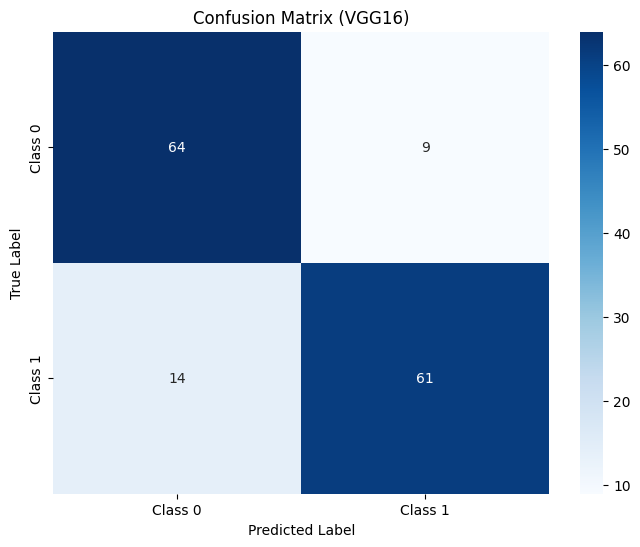

Image 1: True Label: 1, Predicted Label: 1
Image 2: True Label: 1, Predicted Label: 1
Image 3: True Label: 0, Predicted Label: 0
Image 4: True Label: 1, Predicted Label: 1
Image 5: True Label: 1, Predicted Label: 1
Image 6: True Label: 0, Predicted Label: 0
Image 7: True Label: 0, Predicted Label: 0
Image 8: True Label: 0, Predicted Label: 0
Image 9: True Label: 1, Predicted Label: 1
Image 10: True Label: 1, Predicted Label: 1
Image 11: True Label: 1, Predicted Label: 0
Image 12: True Label: 0, Predicted Label: 0
Image 13: True Label: 0, Predicted Label: 0
Image 14: True Label: 0, Predicted Label: 0
Image 15: True Label: 0, Predicted Label: 0
Image 16: True Label: 0, Predicted Label: 0
Image 17: True Label: 1, Predicted Label: 1
Image 18: True Label: 0, Predicted Label: 1
Image 19: True Label: 1, Predicted Label: 1
Image 20: True Label: 0, Predicted Label: 0
Image 21: True Label: 1, Predicted Label: 1
Image 22: True Label: 1, Predicted Label: 1
Image 23: True Label: 1, Predicted Label:

In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from tensorflow.keras.models import load_model

# Load the trained VGG16 model
vgg16_model = load_model('./vgg16_model.h5')  # Path to the saved VGG16 model

# Debug: Check test data shape and content
print(f"Test images shape: {test_images.shape}")
print(f"Test labels shape: {test_labels.shape}")
print(f"Sample test labels (one-hot): {test_labels[:10]}")

# Convert one-hot encoded test labels to integer format
test_labels_int = test_labels if len(test_labels.shape) == 1 else np.argmax(test_labels, axis=1)

# Predict using the VGG16 model
vgg16_predictions = vgg16_model.predict(test_images)
vgg16_predicted_classes = np.argmax(vgg16_predictions, axis=1)  # Convert predictions to class indices

# Calculate accuracy
vgg16_test_accuracy = accuracy_score(test_labels_int, vgg16_predicted_classes)
print(f"VGG16 Test Accuracy: {vgg16_test_accuracy * 100:.2f}%")

# Generate classification report
print("\nClassification Report (VGG16):")
target_names = [f"Class {cls}" for cls in np.unique(test_labels_int)]  # Dynamically create target names
print(classification_report(test_labels_int, vgg16_predicted_classes, target_names=target_names))

# Generate confusion matrix
print("\nConfusion Matrix (VGG16):")
vgg16_conf_matrix = confusion_matrix(test_labels_int, vgg16_predicted_classes)
print(vgg16_conf_matrix)

# Optional: Visualize the confusion matrix
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.heatmap(vgg16_conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=target_names, yticklabels=target_names)
plt.title("Confusion Matrix (VGG16)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# Optionally: Print individual predictions for each test image
for i, (true_label, pred_label) in enumerate(zip(test_labels_int, vgg16_predicted_classes)):
    print(f"Image {i + 1}: True Label: {true_label}, Predicted Label: {pred_label}")


In [ ]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

def create_efficientnet_model(input_shape=(224,224,3), num_classes=2):
    base_model = EfficientNetB0(
        weights='imagenet',
        include_top=False,
        input_shape=input_shape
    )

    base_model.trainable = False    # Freeze for now

    model = Sequential([
        base_model,
        GlobalAveragePooling2D(),
        BatchNormalization(),
        Dropout(0.3),

        Dense(128, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),

        Dense(num_classes, activation='softmax')
    ])

    model.compile(
        optimizer=Adam(learning_rate=1e-4),
        loss='sparse_categorical_crossentropy',   # because labels are 0/1
        metrics=['accuracy']
    )

    return model


# Create model
model = create_efficientnet_model((224,224,3), 2)

# Early stopping
early_stop = EarlyStopping(
    patience=10,
    restore_best_weights=True,
    verbose=1
)

# Train
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=30,
    callbacks=[early_stop]
)


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Epoch 1/30
33/33 ━━━━━━━━━━━━━━━━━━━━ 83s 2s/step - accuracy: 0.5420 - loss: 1.0094 - val_accuracy: 0.2615 - val_loss: 0.7038
Epoch 2/30
33/33 ━━━━━━━━━━━━━━━━━━━━ 22s 647ms/step - accuracy: 0.4884 - loss: 1.0003 - val_accuracy: 0.7385 - val_loss: 0.6574
Epoch 3/30
33/33 ━━━━━━━━━━━━━━━━━━━━ 22s 653ms/step - accuracy: 0.4724 - loss: 1.0365 - val_accuracy: 0.7385 - val_loss: 0.6099
Epoch 4/30
33/33 ━━━━━━━━━━━━━━━━━━━━ 22s 656ms/step - accuracy: 0.5389 - loss: 0.8833 - val_accuracy: 0.7385 - val_loss: 0.5981
Epoch 5/30
33/33 ━━━━━━━━━━━━━━━━━━━━ 22s 664ms/step - accuracy: 0.5539 - loss: 0.8853 - val_accuracy: 0.7385 - val_loss: 0.5849
Epoch 6/30
33/33 ━━━━━━━━━━━━━━━━━━━━ 22s 653ms/step - accuracy: 0.6090 - loss: 0.8623 - val_accuracy: 0.7385 - val_loss: 0.5758
Epoch 7/30
33/33 ━━━━━━━━━━━━━━━━━━━━ 22s 657ms/step - accuracy: 0.4790 - loss: 0.9059 - val_accuracy: 0.7385 - val_loss: 0.5751
Epoch 8/30
33/33 ━━━━━━━━━━━━━━━━━━━━ 21s 642ms/s

4/5 ━━━━━━━━━━━━━━━━━━━━ 0s 378ms/step

5/5 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step


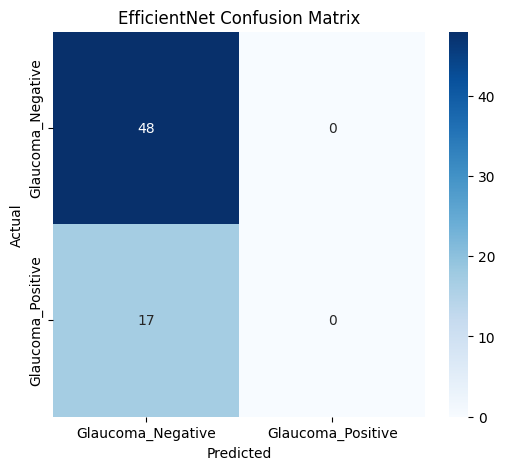

              precision    recall  f1-score   support

           0       0.74      1.00      0.85        48
           1       0.00      0.00      0.00        17

    accuracy                           0.74        65
   macro avg       0.37      0.50      0.42        65
weighted avg       0.55      0.74      0.63        65



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# True labels
y_true = test_generator.classes

# Predictions
y_pred_probs = model.predict(test_generator)
y_pred = np.argmax(y_pred_probs, axis=1)

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

# Plot
plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=test_generator.class_indices.keys(),
    yticklabels=test_generator.class_indices.keys()
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("EfficientNet Confusion Matrix")
plt.show()

# Optional: Classification report
print(classification_report(y_true, y_pred))


In [ ]:
# Grad-CAM++ helper functions
import tensorflow as tf
import numpy as np
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import Model
import matplotlib.pyplot as plt
from PIL import Image

def gradcam_plus_plus_vgg(model, img_array, last_conv_layer_name="block5_conv3", class_index=None, upsample_size=(224,224)):
    last_conv_layer = model.get_layer(last_conv_layer_name)
    grad_model = Model([model.inputs], [last_conv_layer.output, model.output])

    # Use persistent tapes so we can take multiple derivatives
    with tf.GradientTape(persistent=True) as tape1:
        with tf.GradientTape(persistent=True) as tape2:
            conv_outputs, preds = grad_model(img_array)
            if class_index is None:
                class_index = tf.argmax(preds[0])
            loss = preds[:, class_index]
        grads = tape2.gradient(loss, conv_outputs)
        del tape2  # free memory
    first_derivative = grads
    second_derivative = tape1.gradient(first_derivative, conv_outputs)
    third_derivative = tape1.gradient(second_derivative, conv_outputs)
    del tape1  # free memory

    conv_outputs = conv_outputs[0].numpy()
    grads = grads[0].numpy()
    second_derivative = np.zeros_like(grads) if second_derivative is None else second_derivative[0].numpy()
    third_derivative = np.zeros_like(grads) if third_derivative is None else third_derivative[0].numpy()

    global_sum = np.sum(conv_outputs, axis=(0,1))
    alpha_num = second_derivative
    alpha_denom = 2.0 * second_derivative + third_derivative * global_sum[np.newaxis, np.newaxis, :]
    alpha_denom = np.where(alpha_denom != 0.0, alpha_denom, 1e-8)
    alphas = np.maximum(alpha_num / alpha_denom, 0.0)
    weights = np.sum(alphas * np.maximum(grads, 0.0), axis=(0,1))
    cam = np.sum(weights[np.newaxis, np.newaxis, :] * conv_outputs, axis=-1)
    cam = np.maximum(cam, 0)
    if np.max(cam) != 0:
        cam = cam / np.max(cam)
    cam = tf.image.resize(cam[..., np.newaxis], upsample_size).numpy().squeeze()
    return np.clip(cam, 0, 1)


def preprocess_and_show(img_path, model, last_conv_layer_name="block5_conv3", save_to=None):
    img = Image.open(img_path).convert("RGB").resize((224,224))
    x = np.array(img, dtype=np.float32)
    x_exp = np.expand_dims(x, axis=0)
    x_pp = tf.keras.applications.vgg16.preprocess_input(x_exp)
    preds = model.predict(x_pp)
    pred_class = np.argmax(preds[0])
    heatmap = gradcam_plus_plus_vgg(model, x_pp, last_conv_layer_name, pred_class)
    plt.imshow(img)
    plt.imshow(heatmap, cmap='jet', alpha=0.45)
    plt.axis('off')
    plt.title(f'Pred: {pred_class}, Prob: {preds[0][pred_class]:.3f}')
    if save_to:
        plt.savefig(save_to, bbox_inches='tight', dpi=150)
    plt.show()


In [ ]:
def score_cam_vgg(model, img_array, last_conv_layer_name="block5_conv3",
                  class_index=None, upsample_size=(224, 224)):
    """
    Pure TensorFlow / NumPy Score-CAM for VGG-like models.
    img_array: preprocessed input, shape (1, H, W, 3)
    """
    # 1) Get conv feature maps and predictions
    last_conv_layer = model.get_layer(last_conv_layer_name)
    conv_model = Model([model.inputs], [last_conv_layer.output, model.output])

    conv_outputs, preds = conv_model(img_array)
    if class_index is None:
        class_index = tf.argmax(preds[0]).numpy()

    conv_outputs = conv_outputs[0].numpy()     # (h, w, c)
    h, w, n_channels = conv_outputs.shape

    # 2) For each channel, upsample, normalize, use as mask -> get class score
    weights = []

    for k in range(n_channels):
        fmap = conv_outputs[..., k]                             # (h, w)
        fmap_resized = tf.image.resize(fmap[..., np.newaxis],
                                       upsample_size).numpy().squeeze()

        fmin, fmax = fmap_resized.min(), fmap_resized.max()
        if fmax - fmin < 1e-8:
            weights.append(0.0)
            continue

        fmap_norm = (fmap_resized - fmin) / (fmax - fmin + 1e-8)  # [0,1]

        # mask shape: (1, H, W, 1) -> broadcasted over channels
        mask = np.expand_dims(fmap_norm, axis=(0, -1))
        masked_input = img_array * mask                           # (1, H, W, 3)

        # forward pass with masked input to get class score
        score = model.predict(masked_input, verbose=0)[0][class_index]
        weights.append(score)

    weights = np.array(weights, dtype=np.float32)
    if np.sum(weights) != 0:
        weights = weights / (np.sum(weights) + 1e-8)

    # 3) Weighted sum of conv feature maps (like CAM)
    cam = np.zeros((h, w), dtype=np.float32)
    for k, w_k in enumerate(weights):
        cam += w_k * conv_outputs[..., k]

    cam = np.maximum(cam, 0)
    if cam.max() != 0:
        cam = cam / cam.max()

    cam = tf.image.resize(cam[..., np.newaxis], upsample_size).numpy().squeeze()
    return np.clip(cam, 0, 1)


In [ ]:
def preprocess_and_show_scorecam(img_path, model, last_conv_layer_name="block5_conv3", save_to=None):
    img = Image.open(img_path).convert("RGB").resize((224, 224))
    x = np.array(img, dtype=np.float32)
    x_exp = np.expand_dims(x, axis=0)
    x_pp = tf.keras.applications.vgg16.preprocess_input(x_exp)

    preds = model.predict(x_pp, verbose=0)
    pred_class = np.argmax(preds[0])

    heatmap = score_cam_vgg(model, x_pp, last_conv_layer_name, pred_class)

    plt.imshow(img)
    plt.imshow(heatmap, cmap='jet', alpha=0.45)
    plt.axis('off')
    plt.title(f'Score-CAM | Pred: {pred_class}, Prob: {preds[0][pred_class]:.3f}')
    if save_to:
        plt.savefig(save_to, bbox_inches='tight', dpi=150)
    plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


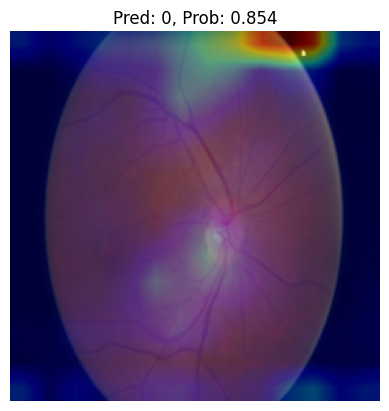

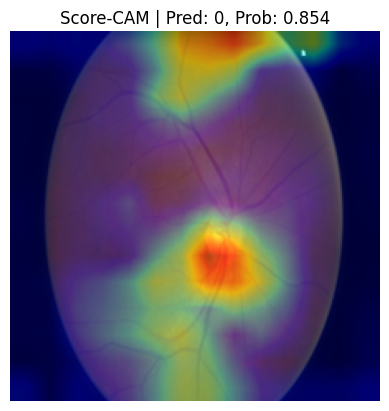

In [ ]:
# --- Grad-CAM++ visualization on one test image ---
test_img_path = "/kaggle/input/glaucoma-detection/Fundus_Train_Val_Data/Fundus_Scanes_Sorted/Validation/Glaucoma_Negative/537.jpg"

preprocess_and_show(
    test_img_path,
    vgg16_model,
    last_conv_layer_name="block5_conv3"
)

# --- Score-CAM visualization on the SAME image ---
preprocess_and_show_scorecam(
    test_img_path,
    vgg16_model,
    last_conv_layer_name="block5_conv3"
)


In [ ]:
def saliency_vgg(model, img_array, class_index=None):
    """
    Vanilla saliency: gradient of class score w.r.t. input pixels.
    img_array: preprocessed input, shape (1, H, W, 3)
    """
    img_tensor = tf.convert_to_tensor(img_array)

    with tf.GradientTape() as tape:
        tape.watch(img_tensor)
        preds = model(img_tensor)
        if class_index is None:
            class_index = tf.argmax(preds[0])
        class_score = preds[:, class_index]

    grads = tape.gradient(class_score, img_tensor)[0].numpy()  # (H, W, 3)
    grads = np.abs(grads)
    saliency = np.max(grads, axis=-1)  # (H, W)

    # normalize to [0, 1]
    saliency -= saliency.min()
    saliency /= (saliency.max() + 1e-8)

    return saliency


def preprocess_and_show_saliency(img_path, model, save_to=None):
    img = Image.open(img_path).convert("RGB").resize((224, 224))
    x = np.array(img, dtype=np.float32)
    x_exp = np.expand_dims(x, axis=0)
    x_pp = tf.keras.applications.vgg16.preprocess_input(x_exp)

    preds = model.predict(x_pp, verbose=0)
    pred_class = np.argmax(preds[0])

    saliency = saliency_vgg(model, x_pp, pred_class)

    plt.imshow(img)
    plt.imshow(saliency, cmap='jet', alpha=0.5)
    plt.axis('off')
    plt.title(f'Saliency | Pred: {pred_class}, Prob: {preds[0][pred_class]:.3f}')
    if save_to:
        plt.savefig(save_to, bbox_inches='tight', dpi=150)
    plt.show()


In [ ]:
def smoothgrad_vgg(model, img_array, class_index=None, n_samples=25, noise_stddev=0.1):
    """
    SmoothGrad: average saliency over noisy copies of the input.
    img_array: preprocessed input, shape (1, H, W, 3)
    """
    if class_index is None:
        preds = model.predict(img_array, verbose=0)
        class_index = np.argmax(preds[0])

    H, W = img_array.shape[1], img_array.shape[2]
    accumulated = np.zeros((H, W), dtype=np.float32)

    # estimate scale for noise from data
    data_std = np.std(img_array)

    for _ in range(n_samples):
        noise = np.random.normal(0, noise_stddev * data_std, size=img_array.shape)
        noisy_img = img_array + noise
        sal = saliency_vgg(model, noisy_img, class_index)
        accumulated += sal

    smooth = accumulated / n_samples
    smooth -= smooth.min()
    smooth /= (smooth.max() + 1e-8)
    return smooth


def preprocess_and_show_smoothgrad(img_path, model, save_to=None,
                                   n_samples=25, noise_stddev=0.1):
    img = Image.open(img_path).convert("RGB").resize((224, 224))
    x = np.array(img, dtype=np.float32)
    x_exp = np.expand_dims(x, axis=0)
    x_pp = tf.keras.applications.vgg16.preprocess_input(x_exp)

    preds = model.predict(x_pp, verbose=0)
    pred_class = np.argmax(preds[0])

    smooth = smoothgrad_vgg(model, x_pp, pred_class,
                            n_samples=n_samples, noise_stddev=noise_stddev)

    plt.imshow(img)
    plt.imshow(smooth, cmap='jet', alpha=0.5)
    plt.axis('off')
    plt.title(f'SmoothGrad | Pred: {pred_class}, Prob: {preds[0][pred_class]:.3f}')
    if save_to:
        plt.savefig(save_to, bbox_inches='tight', dpi=150)
    plt.show()


In [ ]:
def occlusion_vgg_raw(model, img_raw, class_index=None, patch_size=32):
    """
    Occlusion sensitivity on RAW RGB image (H, W, 3).
    We preprocess inside before every forward pass.
    """
    img_raw = np.array(img_raw, dtype=np.float32)
    H, W, _ = img_raw.shape

    # Base prediction
    x = np.expand_dims(img_raw, axis=0)
    x_pp = tf.keras.applications.vgg16.preprocess_input(x)
    base_pred = model.predict(x_pp, verbose=0)[0]

    if class_index is None:
        class_index = np.argmax(base_pred)

    base_score = base_pred[class_index]

    heatmap = np.zeros((H, W), dtype=np.float32)

    # For each patch, zero it (or mean) and see drop in score
    mean_val = img_raw.mean(axis=(0, 1), keepdims=True)  # (1,1,3)

    for i in range(0, H, patch_size):
        for j in range(0, W, patch_size):
            occluded = img_raw.copy()

            # Try either full black or mean; mean is softer
            occluded[i:i+patch_size, j:j+patch_size, :] = mean_val

            x_occ = np.expand_dims(occluded, axis=0)
            x_occ_pp = tf.keras.applications.vgg16.preprocess_input(x_occ)
            pred_occ = model.predict(x_occ_pp, verbose=0)[0][class_index]

            diff = base_score - pred_occ  # drop in confidence
            heatmap[i:i+patch_size, j:j+patch_size] = diff

    # Normalize to [0,1]
    h_min, h_max = heatmap.min(), heatmap.max()
    if h_max - h_min > 1e-8:
        heatmap = (heatmap - h_min) / (h_max - h_min)
    else:
        heatmap = np.zeros_like(heatmap)

    return heatmap


def preprocess_and_show_occlusion(img_path, model, patch_size=32, save_to=None):
    img = Image.open(img_path).convert("RGB").resize((224, 224))
    img_raw = np.array(img, dtype=np.float32)

    # For title only: base prediction on the original
    x = np.expand_dims(img_raw, axis=0)
    x_pp = tf.keras.applications.vgg16.preprocess_input(x)
    preds = model.predict(x_pp, verbose=0)
    pred_class = np.argmax(preds[0])

    occ = occlusion_vgg_raw(model, img_raw,
                            class_index=pred_class,
                            patch_size=patch_size)

    plt.imshow(img)
    plt.imshow(occ, cmap='jet', alpha=0.5)
    plt.axis('off')
    plt.title(f'Occlusion | Pred: {pred_class}, Prob: {preds[0][pred_class]:.3f}')
    if save_to:
        plt.savefig(save_to, bbox_inches='tight', dpi=150)
    plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


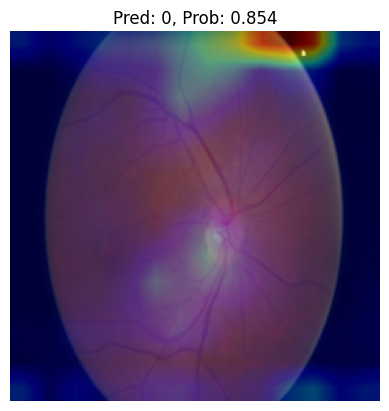

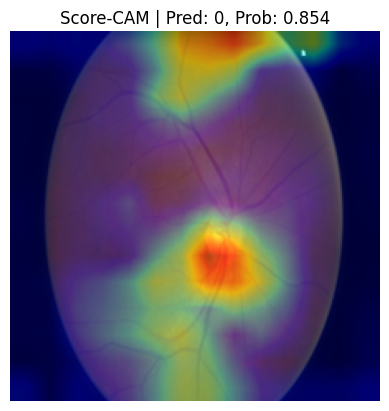

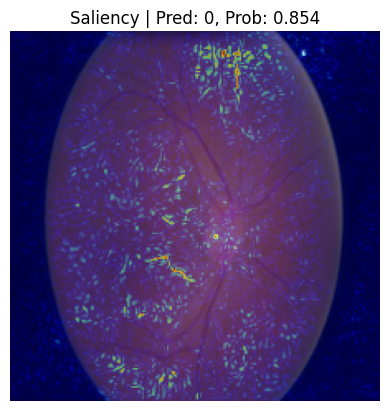

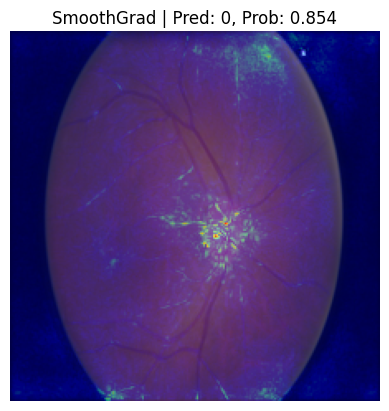

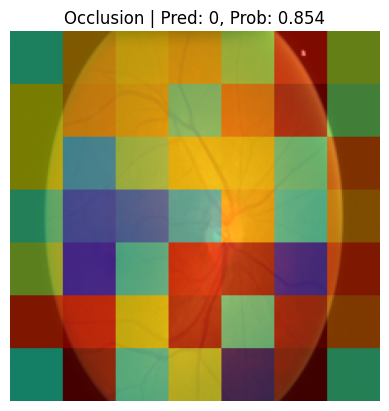

In [ ]:
test_img_path = "/kaggle/input/glaucoma-detection/Fundus_Train_Val_Data/Fundus_Scanes_Sorted/Validation/Glaucoma_Negative/537.jpg"

# Existing:
preprocess_and_show(test_img_path, vgg16_model)             # Grad-CAM++
preprocess_and_show_scorecam(test_img_path, vgg16_model)    # Score-CAM

# New:
preprocess_and_show_saliency(test_img_path, vgg16_model)          # Saliency
preprocess_and_show_smoothgrad(test_img_path, vgg16_model)        # SmoothGrad
preprocess_and_show_occlusion(test_img_path, vgg16_model, 32)     # Occlusion


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from PIL import Image

def get_xai_overlays_for_figure(img_path, model,
                                last_conv_layer_name="block5_conv3",
                                patch_size=32):
    """
    Returns a list of 6 RGB images (0–1 floats):
    [original, gradcam++, score-cam, saliency, smoothgrad, occlusion]
    for the given image path and model.
    """
    # --- load & preprocess image ---
    img = Image.open(img_path).convert("RGB").resize((224, 224))
    img_arr = np.array(img, dtype=np.float32)           # (H,W,3), 0–255
    x_exp = np.expand_dims(img_arr, axis=0)             # (1,H,W,3)
    x_pp  = tf.keras.applications.vgg16.preprocess_input(x_exp)

    # --- prediction & target class ---
    preds = model.predict(x_pp, verbose=0)
    pred_class = np.argmax(preds[0])

    # --- get raw heatmaps (0–1) ---
    gc_pp = gradcam_plus_plus_vgg(model, x_pp,
                                  last_conv_layer_name,
                                  pred_class)           # (H,W)

    sc    = score_cam_vgg(model, x_pp,
                          last_conv_layer_name,
                          pred_class)                  # (H,W)

    sal   = saliency_vgg(model, x_pp, pred_class)      # (H,W)

    sm    = smoothgrad_vgg(model, x_pp, pred_class)    # (H,W)

    occ   = occlusion_vgg_raw(model, img_arr,
                              class_index=pred_class,
                              patch_size=patch_size)   # (H,W)

    # --- convert heatmaps to RGB overlays ---
    def overlay(heatmap_2d, base_img):
        # heatmap_2d: (H,W) in [0,1]
        # base_img: (H,W,3) in 0–255
        base = base_img.astype(np.float32) / 255.0
        hm_rgb = cm.jet(heatmap_2d)[..., :3]  # (H,W,3), 0–1
        out = 0.4 * hm_rgb + 0.6 * base
        return np.clip(out, 0, 1)

    overlay_gc   = overlay(gc_pp,  img_arr)
    overlay_sc   = overlay(sc,     img_arr)
    overlay_sal  = overlay(sal,    img_arr)
    overlay_sm   = overlay(sm,     img_arr)
    overlay_occ  = overlay(occ,    img_arr)

    original_norm = img_arr.astype(np.float32) / 255.0

    return [
        original_norm,
        overlay_gc,
        overlay_sc,
        overlay_sal,
        overlay_sm,
        overlay_occ
    ]


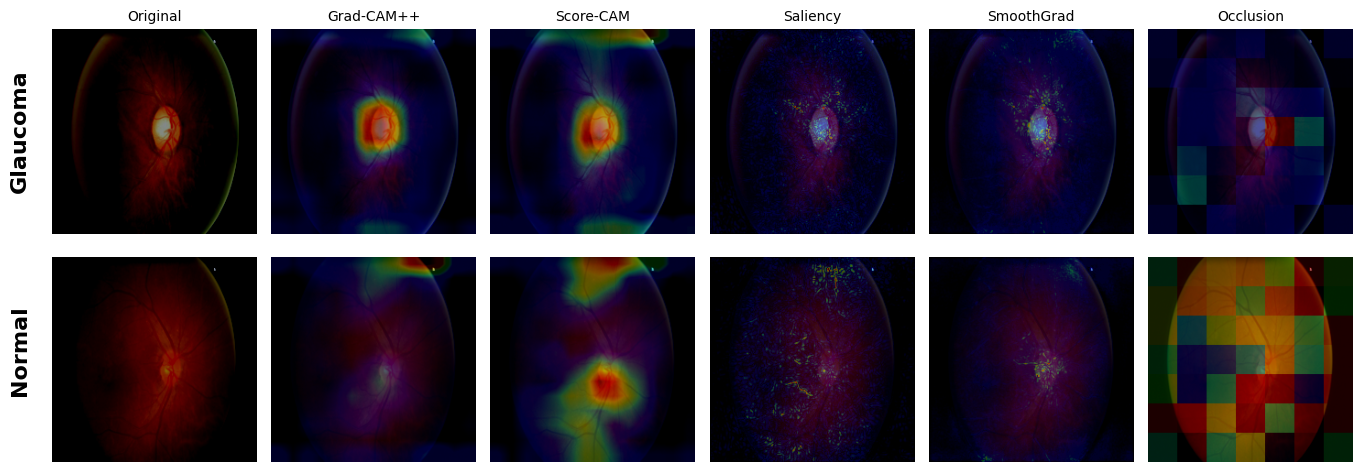

In [ ]:
# paths you want to showcase in the paper
glaucoma_img_path = "/kaggle/input/glaucoma-detection/Fundus_Train_Val_Data/Fundus_Scanes_Sorted/Validation/Glaucoma_Positive/623.jpg"
normal_img_path   = "/kaggle/input/glaucoma-detection/Fundus_Train_Val_Data/Fundus_Scanes_Sorted/Validation/Glaucoma_Negative/537.jpg"

# get overlays
row_glaucoma = get_xai_overlays_for_figure(glaucoma_img_path, vgg16_model)
row_normal   = get_xai_overlays_for_figure(normal_img_path,    vgg16_model)

titles = ["Original",
          "Grad-CAM++",
          "Score-CAM",
          "Saliency",
          "SmoothGrad",
          "Occlusion"]

fig, axes = plt.subplots(2, 6, figsize=(14, 5))

# top row — glaucoma
for j in range(6):
    axes[0, j].imshow(row_glaucoma[j])
    axes[0, j].axis("off")
    axes[0, j].set_title(titles[j], fontsize=10, pad=6)

# bottom row — normal
for j in range(6):
    axes[1, j].imshow(row_normal[j])
    axes[1, j].axis("off")

# tighten spacing before adding labels
plt.tight_layout()
fig.subplots_adjust(left=0.06)

# add clean row labels outside the grid
fig.text(0.03, 0.72, "Glaucoma", fontsize=16, fontweight='bold',
         rotation=90, va='center')
fig.text(0.03, 0.28, "Normal", fontsize=16, fontweight='bold',
         rotation=90, va='center')

plt.show()

# optional — save high-res for research paper
# fig.savefig("glaucoma_xai_panel.png", dpi=400, bbox_inches="tight")


In [ ]:
fig.savefig("glaucoma_xai_panel.png", dpi=400, bbox_inches="tight")
from google.colab import files
files.download("glaucoma_xai_panel.png")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>